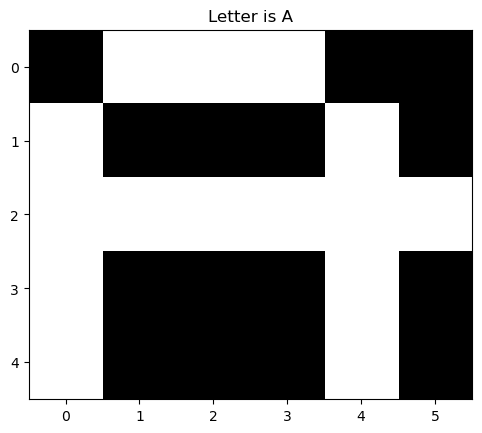

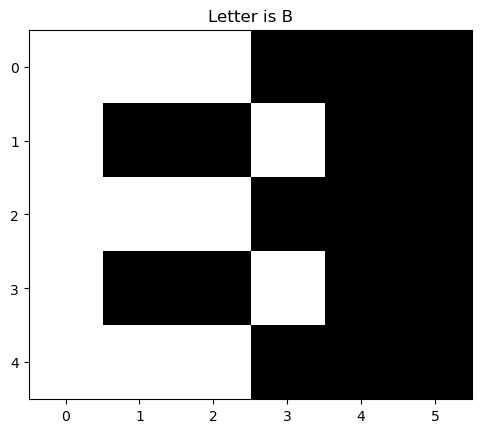

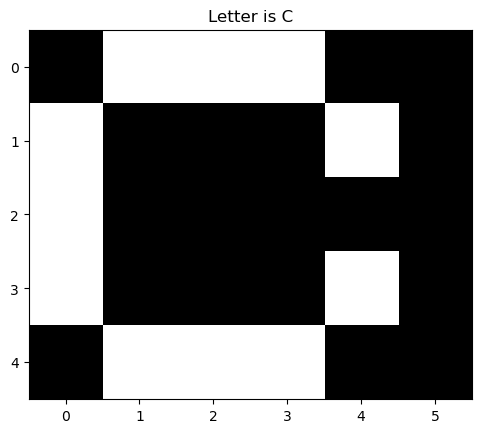

In [1]:
import numpy as np
import matplotlib.pyplot as plt

A=np.array([
    [0,1,1,1,0,0],
    [1,0,0,0,1,0],
    [1,1,1,1,1,1],
    [1,0,0,0,1,0],
    [1,0,0,0,1,0]
])

B=np.array([
    [1,1,1,0,0,0],
    [1,0,0,1,0,0],
    [1,1,1,0,0,0],
    [1,0,0,1,0,0],
    [1,1,1,0,0,0]
])

C=np.array([
    [0,1,1,1,0,0],
    [1,0,0,0,1,0],
    [1,0,0,0,0,0],
    [1,0,0,0,1,0],
    [0,1,1,1,0,0]
])


X=np.array([A.flatten(),B.flatten(),C.flatten()])

#one hot labels A=[1,0,0] , B=[0,1,0], C=[0,0,1]
y=np.array([
    [1,0,0],
    [0,1,0],
    [0,0,1]
])

#visualize the letters

for i, letter in enumerate([A,B,C]):
    plt.imshow(letter,cmap='gray')
    plt.title(f"Letter is {'ABC'[i]}")
    plt.show()

In [2]:
#Part2 now we are initializng the neural networks here 
input_size=30 #number of pixels
hidden_size=10 #hidden neurons
output_size=3 #classes: A,B,C
learning_rate=0.5

#random weight initialization
np.random.seed(42)
w1=np.random.rand(input_size,hidden_size)
b1=np.zeros((1,hidden_size))
w2=np.random.rand(hidden_size,output_size)
b2=np.zeros((1,output_size))

#now definig the sigmoid activation and derivate fucnction
def sigmoid(x):
    return 1/(1+np.exp(-x))

def sigmoid_derivate(x):
    return x*(1-x)

    

In [4]:
#part3: Training (Feedforward+Backpropogation)

In [5]:
epochs=5000
losses=[]

for epoch in range(epochs):

    #feedfprward
    z1=np.dot(X,w1)+b1
    a1=sigmoid(z1)
    z2=np.dot(a1,w2)+b2
    output=sigmoid(z2)

    #compute the loss (Mean Squared Error)
    loss=np.mean((y-output)**2)
    losses.append(loss)

    #BackPropogation
    error=y-output
    d_output=error*sigmoid_derivate(output)

    error_hidden=np.dot(d_output,w2.T)
    d_hidden=error_hidden*sigmoid_derivate(a1)

    #update weights and biases
    w2+=learning_rate*np.dot(a1.T,d_output)
    b2+=learning_rate*np.sum(d_output,axis=0,keepdims=True)
    w1+=learning_rate*np.dot(X.T,d_hidden)
    b1+=learning_rate*np.sum(d_hidden,axis=0,keepdims=True)

    #print progress
    if (epoch+1) % 1000==0:
        print(f"Epoch {epoch+1}/{epochs}-Loss:{loss:4f}")

    

    

Epoch 1000/5000-Loss:0.003970
Epoch 2000/5000-Loss:0.001205
Epoch 3000/5000-Loss:0.000707
Epoch 4000/5000-Loss:0.000499
Epoch 5000/5000-Loss:0.000385


In [6]:
#Part 4 :Visualize Loss

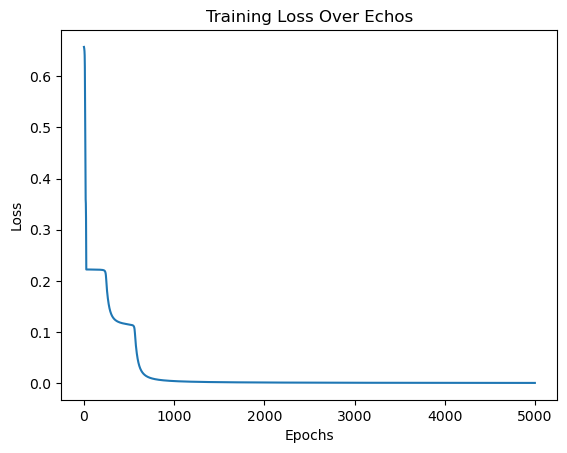

In [8]:
plt.plot(losses)
plt.title("Training Loss Over Echos")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

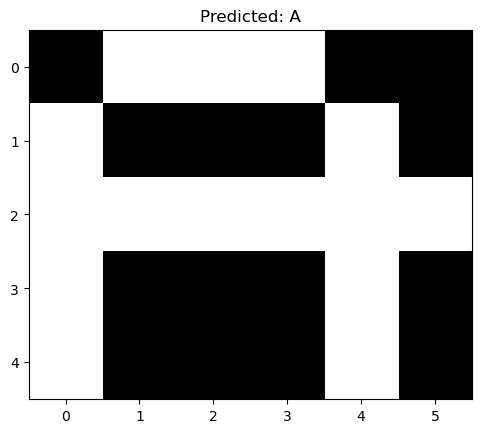

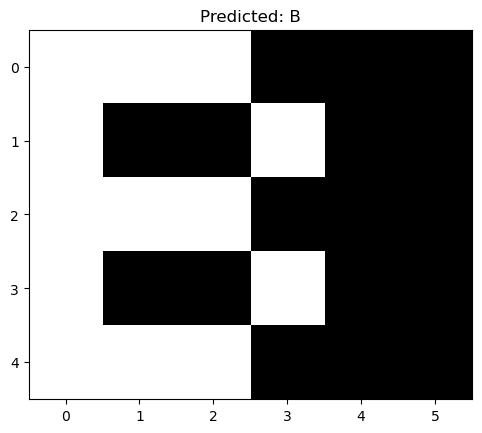

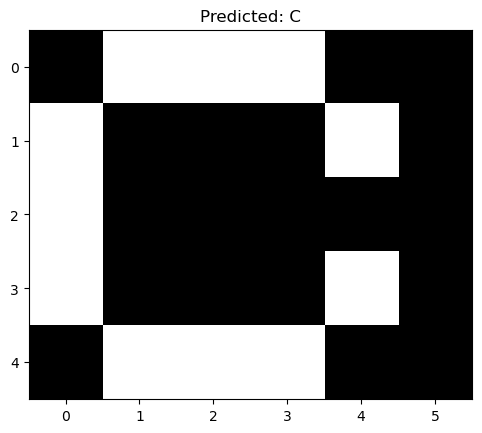

In [9]:
#Part 5: Test Predictins

predictions=np.argmax(output,axis=1)
for i,pred in enumerate(predictions):
    plt.imshow(X[i].reshape(5,6),cmap='gray')
    plt.title(f"Predicted: {'ABC'[pred]}")
    plt.show()